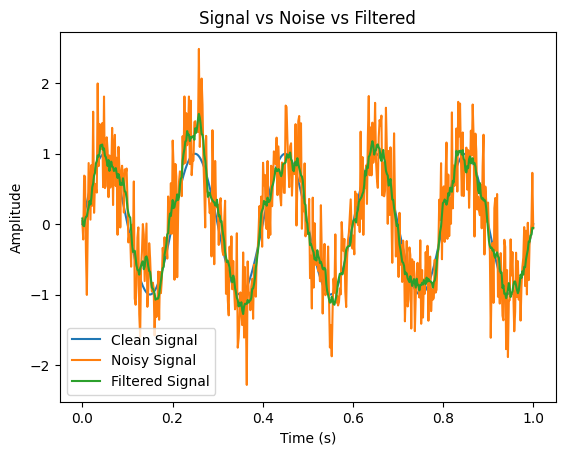

In [13]:
# DIGITAL SIGNAL CONDITIONING SYSTEM

import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 500) # 500 points from 0 to 1 second (0, 0.002..., 1)
signal = np.sin(2 * np.pi * 5 * t) # Sine wave of 5 Hz
noise = np.random.normal(0, 0.5, t.shape) # Gaussian noise
noisy_signal = signal + noise

window_size = 10 # Filter size

filtered_signal = np.convolve(noisy_signal, np.ones(window_size)/window_size, mode='same')

plt.figure()
plt.plot(t, signal, label="Clean Signal")
plt.plot(t, noisy_signal, label="Noisy Signal")
plt.plot(t, filtered_signal, label="Filtered Signal")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal vs Noise vs Filtered")
plt.show()

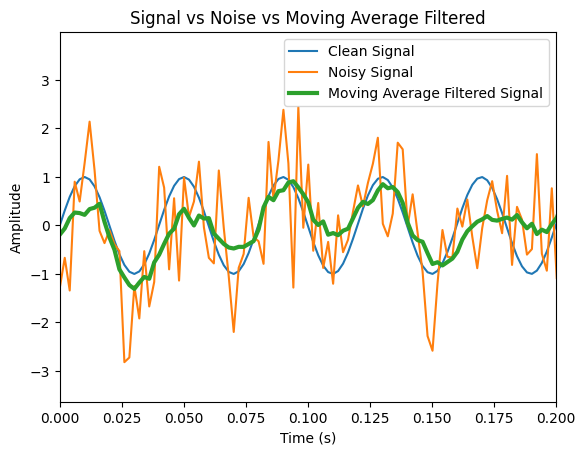

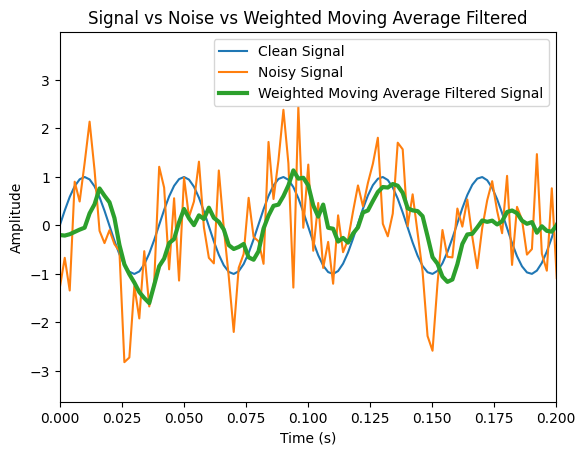

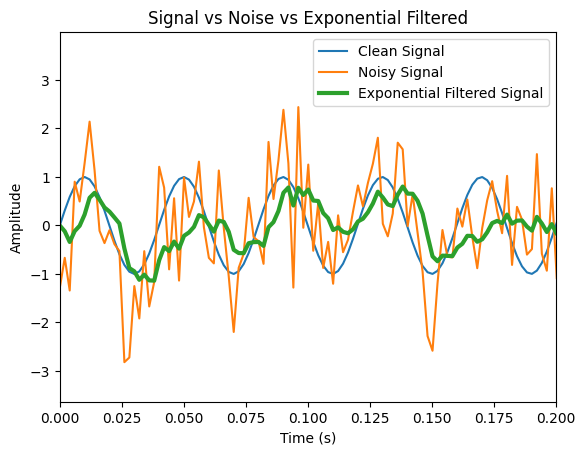

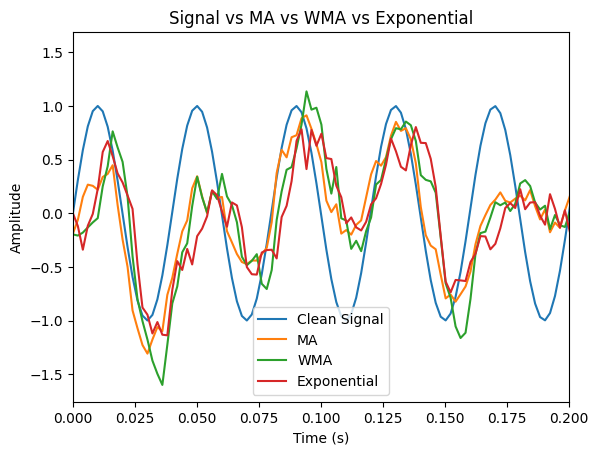

In [39]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 500)
signal = np.sin(2 * np.pi * 25 * t)
noise = np.random.normal(0, 1, t.shape)
noisy_signal = signal + noise

# Moving Average Filter

window_size = 10
np.ones(window_size)/window_size
ma_filtered = np.convolve(noisy_signal, np.ones(window_size)/window_size, mode='same')

plt.figure()
plt.plot(t, signal, label = "Clean Signal")
plt.plot(t, noisy_signal, label = "Noisy Signal")
plt.xlim(0, 0.2)
plt.plot(t, ma_filtered, label = "Moving Average Filtered Signal", linewidth = 3)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal vs Noise vs Moving Average Filtered")
plt.show()

# Weighted Moving Average Filter

weights = np.linspace(1, window_size, window_size)
weights = weights / np.sum(weights)
wma_filtered = np.convolve(noisy_signal, weights, mode='same')

plt.figure()
plt.plot(t, signal, label = "Clean Signal")
plt.plot(t, noisy_signal, label = "Noisy Signal")
plt.xlim(0, 0.2)
plt.plot(t, wma_filtered, label = "Weighted Moving Average Filtered Signal", linewidth = 3)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal vs Noise vs Weighted Moving Average Filtered")
plt.show()

# Exponential Filter

alpha = 0.18
exp_filter = np.zeros_like(noisy_signal)
for i in range(1, len(noisy_signal)):
  exp_filter[i] = alpha * noisy_signal[i] + (1-alpha) * exp_filter[i-1]

plt.figure()
plt.plot(t, signal, label = "Clean Signal")
plt.plot(t, noisy_signal, label = "Noisy Signal")
plt.xlim(0, 0.2)
plt.plot(t, exp_filter, label = "Exponential Filtered Signal", linewidth = 3)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal vs Noise vs Exponential Filtered")
plt.show()


# Comparision

plt.figure()
plt.plot(t, signal, label= "Clean Signal")
plt.plot(t, ma_filtered, label= "MA")
plt.plot(t, wma_filtered, label= "WMA")
plt.plot(t, exp_filter, label= "Exponential")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 0.2)
plt.title("Signal vs MA vs WMA vs Exponential")
plt.show()

Enter signal frequency (e.g., 25): 5
Enter noise standard deviation (e.g., 1): 0.5
Enter window size (e.g., 10): 10
Enter alpha (0 to 1, e.g., 0.2): 0.18


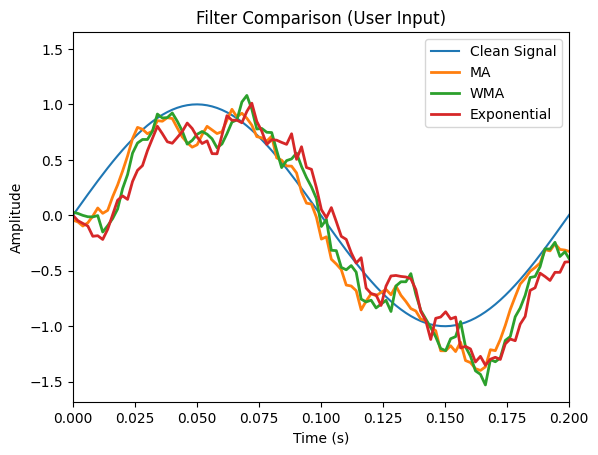

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# User inputs
freq = float(input("Enter signal frequency (e.g., 25): "))
noise_level = float(input("Enter noise standard deviation (e.g., 1): "))
window_size = int(input("Enter window size (e.g., 10): "))
alpha = float(input("Enter alpha (0 to 1, e.g., 0.2): "))

# Time axis
t = np.linspace(0, 1, 500)

# Signal + noise
signal = np.sin(2 * np.pi * freq * t)
noise = np.random.normal(0, noise_level, t.shape)
noisy_signal = signal + noise

# Moving Average
ma_filtered = np.convolve(noisy_signal,
                          np.ones(window_size)/window_size,
                          mode='same')

# Weighted Moving Average
weights = np.linspace(1, window_size, window_size)
weights = weights / np.sum(weights)
wma_filtered = np.convolve(noisy_signal, weights, mode='same')

# Exponential Filter
exp_filter = np.zeros_like(noisy_signal)
for i in range(1, len(noisy_signal)):
    exp_filter[i] = alpha * noisy_signal[i] + (1 - alpha) * exp_filter[i-1]

# Plot comparison
plt.figure()
plt.plot(t, signal, label="Clean Signal")
plt.plot(t, ma_filtered, label="MA", linewidth=2)
plt.plot(t, wma_filtered, label="WMA", linewidth=2)
plt.plot(t, exp_filter, label="Exponential", linewidth=2)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filter Comparison (User Input)")
plt.xlim(0, 0.2)
plt.show()

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def run(freq=25, noise_level=1, window_size=10, alpha=0.2):
    t = np.linspace(0, 1, 500)

    signal = np.sin(2 * np.pi * freq * t)
    noise = np.random.normal(0, noise_level, t.shape)
    noisy_signal = signal + noise

    # Moving Average
    ma = np.convolve(noisy_signal,
                     np.ones(int(window_size))/int(window_size),
                     mode='same')

    # Weighted Moving Average
    weights = np.linspace(1, int(window_size), int(window_size))
    weights = weights / np.sum(weights)
    wma = np.convolve(noisy_signal, weights, mode='same')

    # Exponential Filter
    exp = np.zeros_like(noisy_signal)
    for i in range(1, len(noisy_signal)):
        exp[i] = alpha * noisy_signal[i] + (1 - alpha) * exp[i-1]

    # Plot
    plt.figure()
    plt.plot(t, signal, label="Signal")
    plt.plot(t, ma, label="MA")
    plt.plot(t, wma, label="WMA")
    plt.plot(t, exp, label="Exponential")
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Interactive Filter Comparison")
    plt.xlim(0, 0.2)
    plt.show()

# Sliders
interact(run, freq=(1, 50, 1),
         noise_level=(0.1, 3, 0.1),
         window_size=(2, 50, 1),
         alpha=(0.01, 1.0, 0.01))

interactive(children=(IntSlider(value=25, description='freq', max=50, min=1), FloatSlider(value=1.0, descripti…

<function __main__.run(freq=25, noise_level=1, window_size=10, alpha=0.2)>